# Training Data Viewer

Visualize training examples directly from saved `.npz` files — exactly what the network sees.

In [9]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

GRID = 16
TOKEN_TARGET = 256

def index_to_pos(idx):
    return idx % GRID, idx // GRID

def pos_to_index(x, y):
    return y * GRID + x

# Feature dimension names
DIM_NAMES = [
    'x', 'y', 'wall_N', 'wall_S', 'wall_W', 'wall_E',
    'is_goal', 'is_target_robot', 'is_helper',
    'temporal_before', 'temporal_after',
    'open_edge_start', 'open_edge_end',
    'is_bottleneck', 'is_support_or_leaf',
    'came_from_x', 'came_from_y', 'goes_to_x', 'goes_to_y',
]

## Drawing from features

In [10]:
def _setup_grid(ax):
    """Set up 16x16 grid with cell-boundary lines."""
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(15.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([i - 0.5 for i in range(17)], minor=False)
    ax.set_xticklabels([])
    ax.set_xticks(range(16), minor=True)
    ax.set_xticklabels([str(i) for i in range(16)], minor=True)
    ax.set_yticks([i - 0.5 for i in range(17)], minor=False)
    ax.set_yticklabels([])
    ax.set_yticks(range(16), minor=True)
    ax.set_yticklabels([str(i) for i in range(16)], minor=True)
    ax.tick_params(which='major', length=0)
    ax.tick_params(which='minor', length=0, labelsize=5)
    ax.grid(True, which='major', linewidth=0.3, color='#cccccc')


def _draw_walls(ax, features):
    """Draw walls from dims 2-5."""
    for i in range(256):
        x, y = index_to_pos(i)
        if features[i, 2] > 0 and y > 0:
            ax.plot([x-0.5, x+0.5], [y-0.5, y-0.5], 'k-', lw=2)
        if features[i, 3] > 0 and y < 15:
            ax.plot([x-0.5, x+0.5], [y+0.5, y+0.5], 'k-', lw=2)
        if features[i, 4] > 0 and x > 0:
            ax.plot([x-0.5, x-0.5], [y-0.5, y+0.5], 'k-', lw=2)
        if features[i, 5] > 0 and x < 15:
            ax.plot([x+0.5, x+0.5], [y-0.5, y+0.5], 'k-', lw=2)
    for s in [[-0.5,15.5,-0.5,-0.5],[-0.5,15.5,15.5,15.5],
              [-0.5,-0.5,-0.5,15.5],[15.5,15.5,-0.5,15.5]]:
        ax.plot(s[:2], s[2:], 'k-', lw=3)


def draw_example(features, target, robot_colors=None, meta=None):
    """Draw a complete, self-describing visualization of one training example.

    Left:  The board with everything labeled + legend
    Right: Text panel explaining input/output
    """
    color_map = {'Red':'#e74c3c','Green':'#27ae60','Blue':'#2980b9','Yellow':'#f1c40f'}
    robot_colors = robot_colors or {}

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                   gridspec_kw={'width_ratios': [1.1, 1]})

    # === LEFT: Board ===
    _setup_grid(ax)
    _draw_walls(ax, features)

    # Goal
    goal_cells = np.where(features[:, 6] > 0)[0]
    for idx in goal_cells:
        gx, gy = index_to_pos(idx)
        ax.plot(gx, gy, '*', ms=16, color='gold', mec='black', mew=0.8, zorder=5)
        ax.text(gx, gy + 0.45, 'GOAL', ha='center', va='top',
                fontsize=5, color='#b8860b', fontweight='bold', zorder=8)

    # Target robot (mover)
    for idx in np.where(features[:, 7] > 0)[0]:
        rx, ry = index_to_pos(idx)
        c_name = robot_colors.get(idx, '?')
        fc = color_map.get(c_name, '#e74c3c')
        ax.add_patch(plt.Circle((rx, ry), 0.38, fc=fc, ec='black', lw=1.5, zorder=4))
        ax.text(rx, ry, c_name[0] if c_name != '?' else 'T',
                ha='center', va='center', fontsize=7, fontweight='bold', color='white', zorder=6)
        ax.text(rx, ry + 0.45, 'MOVER', ha='center', va='top',
                fontsize=4, color=fc, fontweight='bold', zorder=8)

    # Helpers
    for idx in np.where(features[:, 8] > 0)[0]:
        rx, ry = index_to_pos(idx)
        c_name = robot_colors.get(idx, '?')
        fc = color_map.get(c_name, '#95a5a6')
        ax.add_patch(plt.Circle((rx, ry), 0.35, fc=fc, ec='black', lw=1, zorder=4))
        ax.text(rx, ry, c_name[0] if c_name != '?' else 'H',
                ha='center', va='center', fontsize=7, fontweight='bold', color='white', zorder=6)

    # Open edge
    start_cells = np.where(features[:, 11] > 0)[0]
    end_cells = np.where(features[:, 12] > 0)[0]
    for idx in start_cells:
        x, y = index_to_pos(idx)
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                     fc='#ff000010', ec='red', lw=2, ls='--', zorder=3))
        ax.text(x, y - 0.42, 'OPEN\nSTART', ha='center', va='top',
                fontsize=3.5, color='red', fontweight='bold', zorder=8)
    for idx in end_cells:
        x, y = index_to_pos(idx)
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                     fc='#ff000010', ec='red', lw=2, ls='--', zorder=3))
        ax.text(x, y - 0.42, 'OPEN\nEND', ha='center', va='top',
                fontsize=3.5, color='red', fontweight='bold', zorder=8)
    if len(start_cells) > 0 and len(end_cells) > 0:
        sx, sy = index_to_pos(start_cells[0])
        ex, ey = index_to_pos(end_cells[0])
        ax.annotate('', xy=(sx, sy), xytext=(ex, ey),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2,
                                  ls='--', connectionstyle='arc3,rad=0.15'), zorder=3)

    # Plan nodes + temporal shading
    for i in range(256):
        x, y = index_to_pos(i)
        ib = features[i, 9] > 0
        ia = features[i, 10] > 0
        if features[i, 13] > 0:
            c = '#8e44ad' if ia else '#27ae60' if ib else '#e74c3c'
            ax.plot(x, y, 's', ms=10, color=c, mec='black', mew=0.8, zorder=7)
        if features[i, 14] > 0:
            c = '#8e44ad' if ia else '#27ae60' if ib else '#2980b9'
            ax.plot(x, y, 'D', ms=9, color=c, mec='black', mew=0.8, zorder=7)
        if ib and not features[i, 13] and not features[i, 14]:
            ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, fc='#27ae60', alpha=0.12, zorder=1))
        if ia and not features[i, 13] and not features[i, 14]:
            ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, fc='#8e44ad', alpha=0.12, zorder=1))

    # Edge encoding arrows
    for i in range(256):
        x, y = index_to_pos(i)
        cf_x, cf_y = features[i, 15], features[i, 16]
        if cf_x > 0 or cf_y > 0:
            ax.annotate('', xy=(x, y), xytext=(cf_x, cf_y),
                       arrowprops=dict(arrowstyle='->', color='#777', lw=0.5,
                                      connectionstyle='arc3,rad=0.08'), zorder=2)

    # Ground truth answer (lime outlines)
    bn_x, bn_y = index_to_pos(int(target[0]))
    sp_x, sp_y = index_to_pos(int(target[1]))
    ax.plot(bn_x, bn_y, 's', ms=16, color='none', mec='lime', mew=3, zorder=9)
    ax.plot(sp_x, sp_y, 'D', ms=15, color='none', mec='lime', mew=3, zorder=9)
    ax.text(bn_x, bn_y + 0.45, 'ANSWER:\nbottleneck', ha='center', va='top',
            fontsize=4, color='lime', fontweight='bold', zorder=9,
            bbox=dict(fc='black', alpha=0.6, pad=1, boxstyle='round,pad=0.2'))
    ax.text(sp_x, sp_y + 0.45, 'ANSWER:\nsupport', ha='center', va='top',
            fontsize=4, color='lime', fontweight='bold', zorder=9,
            bbox=dict(fc='black', alpha=0.6, pad=1, boxstyle='round,pad=0.2'))

    title = 'Training Example'
    if meta:
        title += f' #{meta["global_idx"]} (env {meta["env_id"]}, A* iter {meta["iteration"]})'
    ax.set_title(title, fontsize=11, fontweight='bold')

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=9,
               markeredgecolor='black', label='Goal (target cell)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=7,
               markeredgecolor='black', label='Mover robot (must reach goal)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2980b9', markersize=7,
               markeredgecolor='black', label='Helper robot'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#8e44ad', markersize=7,
               markeredgecolor='black', label='Bottleneck (committed)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#8e44ad', markersize=6,
               markeredgecolor='black', label='Support/leaf (committed)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#27ae60', markersize=7,
               markeredgecolor='black', label='Bottleneck (unsolved)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#27ae60', markersize=6,
               markeredgecolor='black', label='Support/leaf (unsolved)'),
        mpatches.Patch(fc='#8e44ad', alpha=0.25, ec='none',
                       label='Committed zone (after open edge)'),
        mpatches.Patch(fc='#27ae60', alpha=0.25, ec='none',
                       label='Unsolved zone (before open edge)'),
        mpatches.Patch(fc='none', ec='red', ls='--', lw=1.5,
                       label='Open edge (blocked path segment)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='none', markersize=8,
               markeredgecolor='lime', markeredgewidth=2, label='Ground truth answer'),
        Line2D([0], [0], color='#777', lw=0.8, label='Edge encoding arrow'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=5.5,
              framealpha=0.92, fancybox=True, title='SYMBOLS', title_fontsize=6.5)

    # === RIGHT: Text explanation ===
    ax2.axis('off')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

    # Collect info
    info_lines = []

    def add(text, **kw):
        info_lines.append((text, kw))

    add('WHAT IS THIS?', fontsize=11, fontweight='bold', color='black')
    add('')
    add('A training example for a neural network that proposes',
        fontsize=8, color='#333')
    add('subgoals in Ricochet Robots. Robots slide on a 16x16 grid',
        fontsize=8, color='#333')
    add('until hitting a wall or another robot.',
        fontsize=8, color='#333')
    add('')

    add('INPUT  (what the network sees)', fontsize=10, fontweight='bold', color='#222')
    add('')

    if len(goal_cells) > 0:
        gp = index_to_pos(goal_cells[0])
        add(f'  GOAL  at ({gp[0]},{gp[1]})', fontsize=8.5, color='#b8860b')

    for idx in np.where(features[:, 7] > 0)[0]:
        rp = index_to_pos(idx)
        c_name = robot_colors.get(idx, '?')
        add(f'  MOVER  {c_name} at ({rp[0]},{rp[1]})  -- must reach the goal',
            fontsize=8.5, color='#c0392b')

    for idx in np.where(features[:, 8] > 0)[0]:
        rp = index_to_pos(idx)
        c_name = robot_colors.get(idx, '?')
        add(f'  HELPER {c_name} at ({rp[0]},{rp[1]})', fontsize=8.5, color='#2980b9')

    add('')
    add('  PROBLEM  (red dashed boxes on board)', fontsize=8.5, fontweight='bold', color='red')

    if len(start_cells) > 0 and len(end_cells) > 0:
        sp_p = index_to_pos(start_cells[0])
        ep_p = index_to_pos(end_cells[0])
        add(f'    The robot must travel  ({ep_p[0]},{ep_p[1]}) -> ({sp_p[0]},{sp_p[1]})',
            fontsize=8.5, color='#c0392b')
        add(f'    but walls block the direct path.', fontsize=8.5, color='#c0392b')

    bn_count = int((features[:, 13] > 0).sum())
    sp_count = int((features[:, 14] > 0).sum())
    after_c = int((features[:, 10] > 0).sum())
    before_c = int((features[:, 9] > 0).sum())

    if bn_count or sp_count:
        add('')
        add('  PLAN CONTEXT  (squares/diamonds on board)',
            fontsize=8.5, fontweight='bold', color='#555')
        add(f'    {bn_count} bottleneck(s), {sp_count} support/leaf(s)', fontsize=8.5, color='#555')
        if after_c:
            add(f'    Purple = committed plan (above the open edge)', fontsize=8.5, color='#8e44ad')
        if before_c:
            add(f'    Green  = unsolved part  (below the open edge)', fontsize=8.5, color='#27ae60')

    add('')
    add('OUTPUT  (3 tokens the network must predict)', fontsize=10, fontweight='bold', color='#222')
    add('')
    add('  "Place a subgoal so the blocked path becomes possible"',
        fontsize=8, fontstyle='italic', color='#555')
    add('')
    add(f'  Token 1:  BOTTLENECK  ({bn_x},{bn_y})',
        fontsize=9, fontweight='bold', color='#2ecc71')
    add(f'            Mover will pass through this cell', fontsize=8, color='#555')
    add(f'  Token 2:  SUPPORT     ({sp_x},{sp_y})',
        fontsize=9, fontweight='bold', color='#2ecc71')
    add(f'            A robot blocks here so mover stops at bottleneck',
        fontsize=8, color='#555')

    if int(target[2]) == TOKEN_TARGET:
        add(f'  Token 3:  ROBOT = MOVER itself',
            fontsize=9, fontweight='bold', color='#2ecc71')
        add(f'            The moving robot acts as its own blocker', fontsize=8, color='#555')
    else:
        rp = index_to_pos(int(target[2]))
        c_name = robot_colors.get(int(target[2]), '?')
        add(f'  Token 3:  ROBOT = {c_name} at ({rp[0]},{rp[1]})',
            fontsize=9, fontweight='bold', color='#2ecc71')
        add(f'            This helper moves to the support position', fontsize=8, color='#555')

    add('')
    add('  Lime outlines on the board = ground truth answer',
        fontsize=8, color='#2ecc71')

    # Render text lines
    y = 0.98
    for text, kw in info_lines:
        if text == '':
            y -= 0.015
            continue
        fs = kw.pop('fontsize', 8)
        ax2.text(0.02, y, text, transform=ax2.transAxes,
                verticalalignment='top', fontfamily='monospace', fontsize=fs, **kw)
        y -= fs * 0.0025 + 0.018

    plt.tight_layout()
    return fig

## Load training example

In [11]:
# ===== CONFIGURE HERE =====
EXAMPLE_IDX = 88
# ==========================

with open('output_v2/metadata.pkl', 'rb') as f:
    all_metadata = pickle.load(f)

meta = all_metadata[EXAMPLE_IDX]
saved = np.load(f'output_v2/example_{meta["global_idx"]}.npz')
features = saved['features']   # (256, 19)
target = saved['target']       # (3,)
robot_colors = meta.get('robot_colors', {})

print(f'Example #{meta["global_idx"]}  (env={meta["env_id"]}, iter={meta["iteration"]})')
print(f'  open_edge: {meta["open_edge"]}')
print(f'  features:  {features.shape} {features.dtype}')
print(f'  target:    {target}')

# Decode target
bn_pos = index_to_pos(int(target[0]))
sp_pos = index_to_pos(int(target[1]))
print(f'\n  Ground truth:')
print(f'    bottleneck = ({bn_pos[0]},{bn_pos[1]})')
print(f'    support    = ({sp_pos[0]},{sp_pos[1]})')
if int(target[2]) == TOKEN_TARGET:
    print(f'    robot      = TARGET (token {TOKEN_TARGET})')
else:
    rp = index_to_pos(int(target[2]))
    c = robot_colors.get(int(target[2]), '?')
    print(f'    robot      = helper at ({rp[0]},{rp[1]}) [{c}]')

Example #88  (env=13, iter=39)
  open_edge: ('sp_2', 'leaf_2')
  features:  (256, 19) float32
  target:    [177 161 256]

  Ground truth:
    bottleneck = (1,11)
    support    = (1,10)
    robot      = TARGET (token 256)


## Board visualization (from features only)

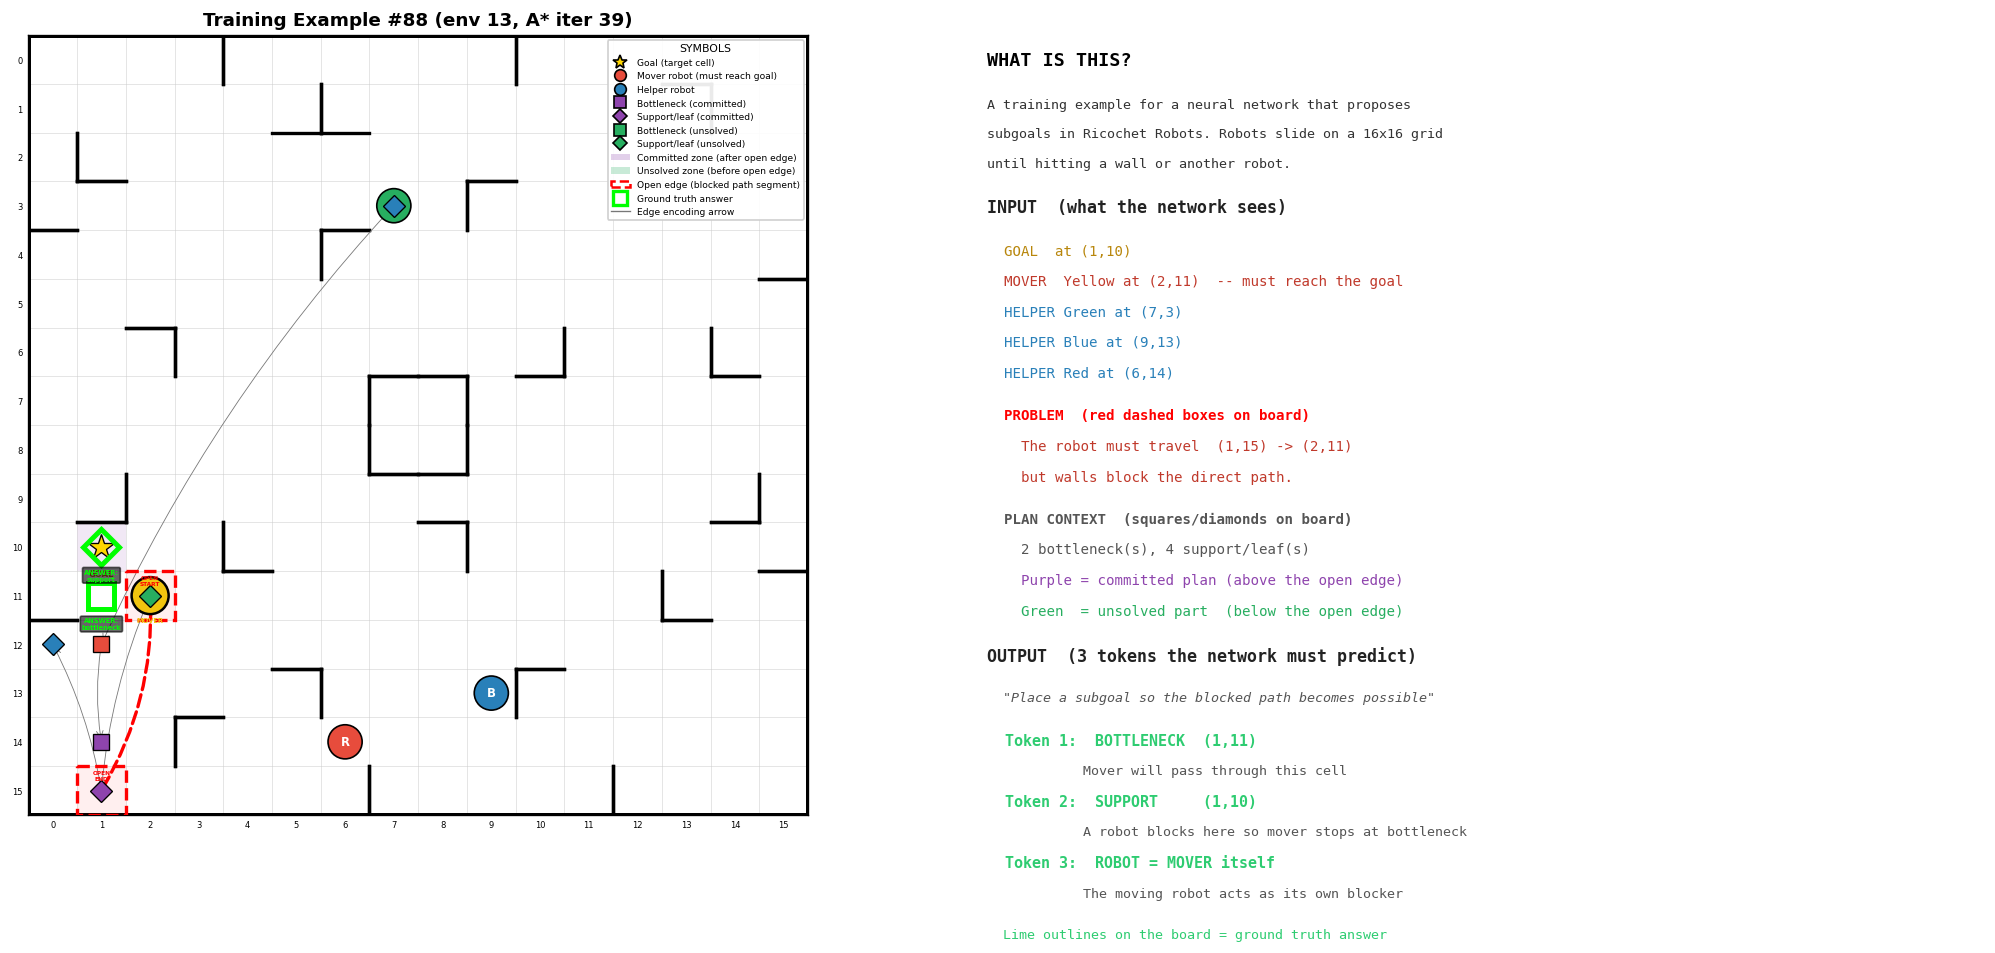

In [12]:
fig = draw_example(features, target, robot_colors=robot_colors, meta=meta)
plt.show()

## Feature heatmaps

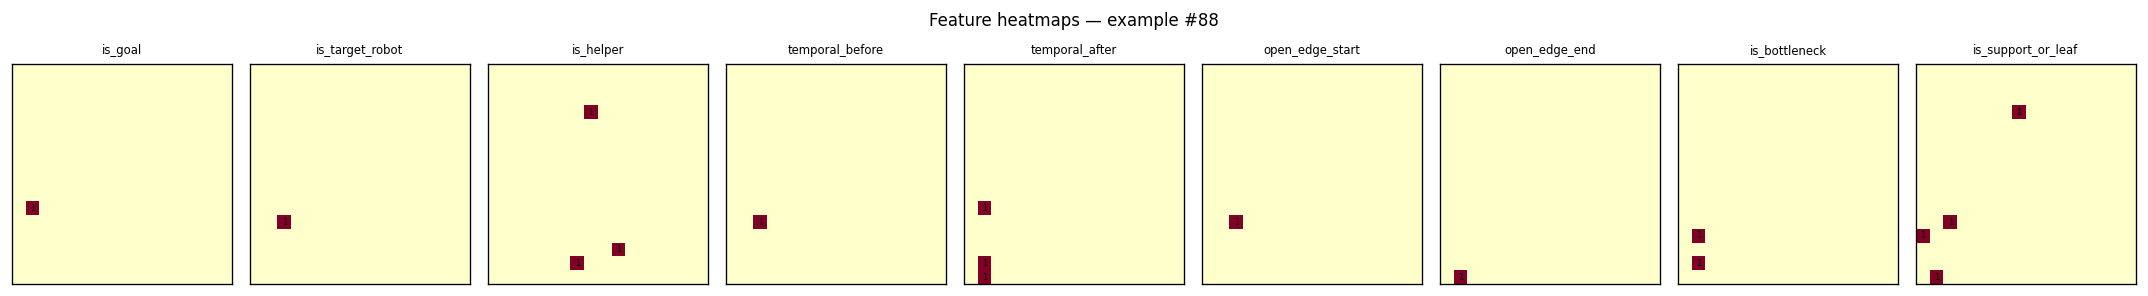

In [13]:
interesting = [6, 7, 8, 9, 10, 11, 12, 13, 14]
fig, axes = plt.subplots(1, len(interesting), figsize=(18, 2.5))

for ax, dim_idx in zip(axes, interesting):
    grid = features[:, dim_idx].reshape(16, 16)
    ax.imshow(grid, cmap='YlOrRd', vmin=0, vmax=1, origin='upper')
    ax.set_title(DIM_NAMES[dim_idx], fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
    for y in range(16):
        for x in range(16):
            if grid[y, x] > 0:
                ax.text(x, y, f'{grid[y,x]:.0f}', ha='center', va='center',
                        fontsize=5, color='black')

plt.suptitle(f'Feature heatmaps — example #{meta["global_idx"]}', fontsize=10)
plt.tight_layout()
plt.show()

## Non-zero plan features per cell

In [14]:
print(f'Non-zero plan features (dims 6-18):\n')
print(f'{"cell":>8s}  {"features"}')
print('-' * 70)
for i in range(256):
    parts = []
    x, y = index_to_pos(i)
    if features[i, 6] > 0: parts.append('GOAL')
    if features[i, 7] > 0: parts.append('TARGET_ROBOT')
    if features[i, 8] > 0: parts.append('HELPER')
    if features[i, 9] > 0: parts.append('BEFORE')
    if features[i, 10] > 0: parts.append('AFTER')
    if features[i, 11] > 0: parts.append('OPEN_START')
    if features[i, 12] > 0: parts.append('OPEN_END')
    if features[i, 13] > 0: parts.append('BOTTLENECK')
    if features[i, 14] > 0: parts.append('SUPPORT/LEAF')
    cf_x, cf_y = features[i, 15], features[i, 16]
    gt_x, gt_y = features[i, 17], features[i, 18]
    if cf_x != 0 or cf_y != 0 or gt_x != 0 or gt_y != 0:
        parts.append(f'from=({cf_x:.0f},{cf_y:.0f}) to=({gt_x:.0f},{gt_y:.0f})')
    if parts:
        print(f'({x:2d},{y:2d})    {"  ".join(parts)}')

Non-zero plan features (dims 6-18):

    cell  features
----------------------------------------------------------------------
( 7, 3)    HELPER  SUPPORT/LEAF  from=(-1,-1) to=(1,12)
( 1,10)    GOAL  AFTER  from=(-1,-1) to=(-1,-1)
( 2,11)    TARGET_ROBOT  BEFORE  OPEN_START  SUPPORT/LEAF  from=(-1,-1) to=(1,15)
( 0,12)    SUPPORT/LEAF  from=(1,15) to=(1,14)
( 1,12)    BOTTLENECK  from=(7,3) to=(1,14)
( 9,13)    HELPER
( 1,14)    AFTER  BOTTLENECK  from=(1,12) to=(1,10)
( 6,14)    HELPER
( 1,15)    AFTER  OPEN_END  SUPPORT/LEAF  from=(2,11) to=(1,10)


## Step-by-step solving trace

Traces back from a complete plan through its ancestor intermediate plans to show how A* built up the solution step by step. Each step adds one subgoal group.

In [ ]:
# ===== CONFIGURE HERE =====
TRACE_ENV_ID = 13
# ==========================

# Load from viz_data.pkl
with open('viz_data.pkl', 'rb') as f:
    viz_data = pickle.load(f)

env_data = viz_data[TRACE_ENV_ID]
grid_env = env_data['grid_env']
state = env_data['state']
all_plans = env_data['plans']

# Separate by category
complete_plans = [p for p in all_plans if p['category'] == 'complete']
intermediate_plans = [p for p in all_plans if p['category'] == 'intermediate']

# Find lineage: ancestor plans whose nodes are a subset of the complete plan
complete_data = complete_plans[0]
complete_nodes = set(complete_data['plan'].g.nodes())

ancestor_plans = [p for p in intermediate_plans
                  if set(p['plan'].g.nodes()) <= complete_nodes]

# Deduplicate by node set (keep earliest iteration)
seen = {}
for pd in ancestor_plans:
    key = frozenset(pd['plan'].g.nodes())
    if key not in seen or pd['iteration'] < seen[key]['iteration']:
        seen[key] = pd
ancestors = sorted(seen.values(), key=lambda pd: (len(pd['plan'].g.nodes()), pd['iteration']))
ancestors.append(complete_data)

print(f'Env {TRACE_ENV_ID}: {len(intermediate_plans)} intermediate plans, '
      f'{len(complete_plans)} complete plan(s)')
print(f'Lineage: {len(ancestors)} steps from initial to complete\n')

for i, pd in enumerate(ancestors):
    plan = pd['plan']
    n_open = sum(1 for _,_,d in plan.g.edges(data=True) if d.get('status') == 'open')
    n_fixed = sum(1 for _,_,d in plan.g.edges(data=True) if d.get('status') == 'fixed')
    subgoals = [n for n in plan.g.nodes() if plan.g.nodes[n].get('ntype') == 'subgoal']
    new_sg = ''
    if i > 0:
        prev_nodes = set(ancestors[i-1]['plan'].g.nodes())
        added = set(plan.g.nodes()) - prev_nodes
        added_sg = [n for n in added if plan.g.nodes[n].get('ntype') == 'subgoal']
        if added_sg:
            new_sg = f'  << NEW: {", ".join(added_sg)}'
    print(f'  Step {i}: iter={pd["iteration"]:3d}, {len(plan.g.nodes()):2d} nodes, '
          f'{n_open} open / {n_fixed} fixed edges, '
          f'subgoals={subgoals}{new_sg}')

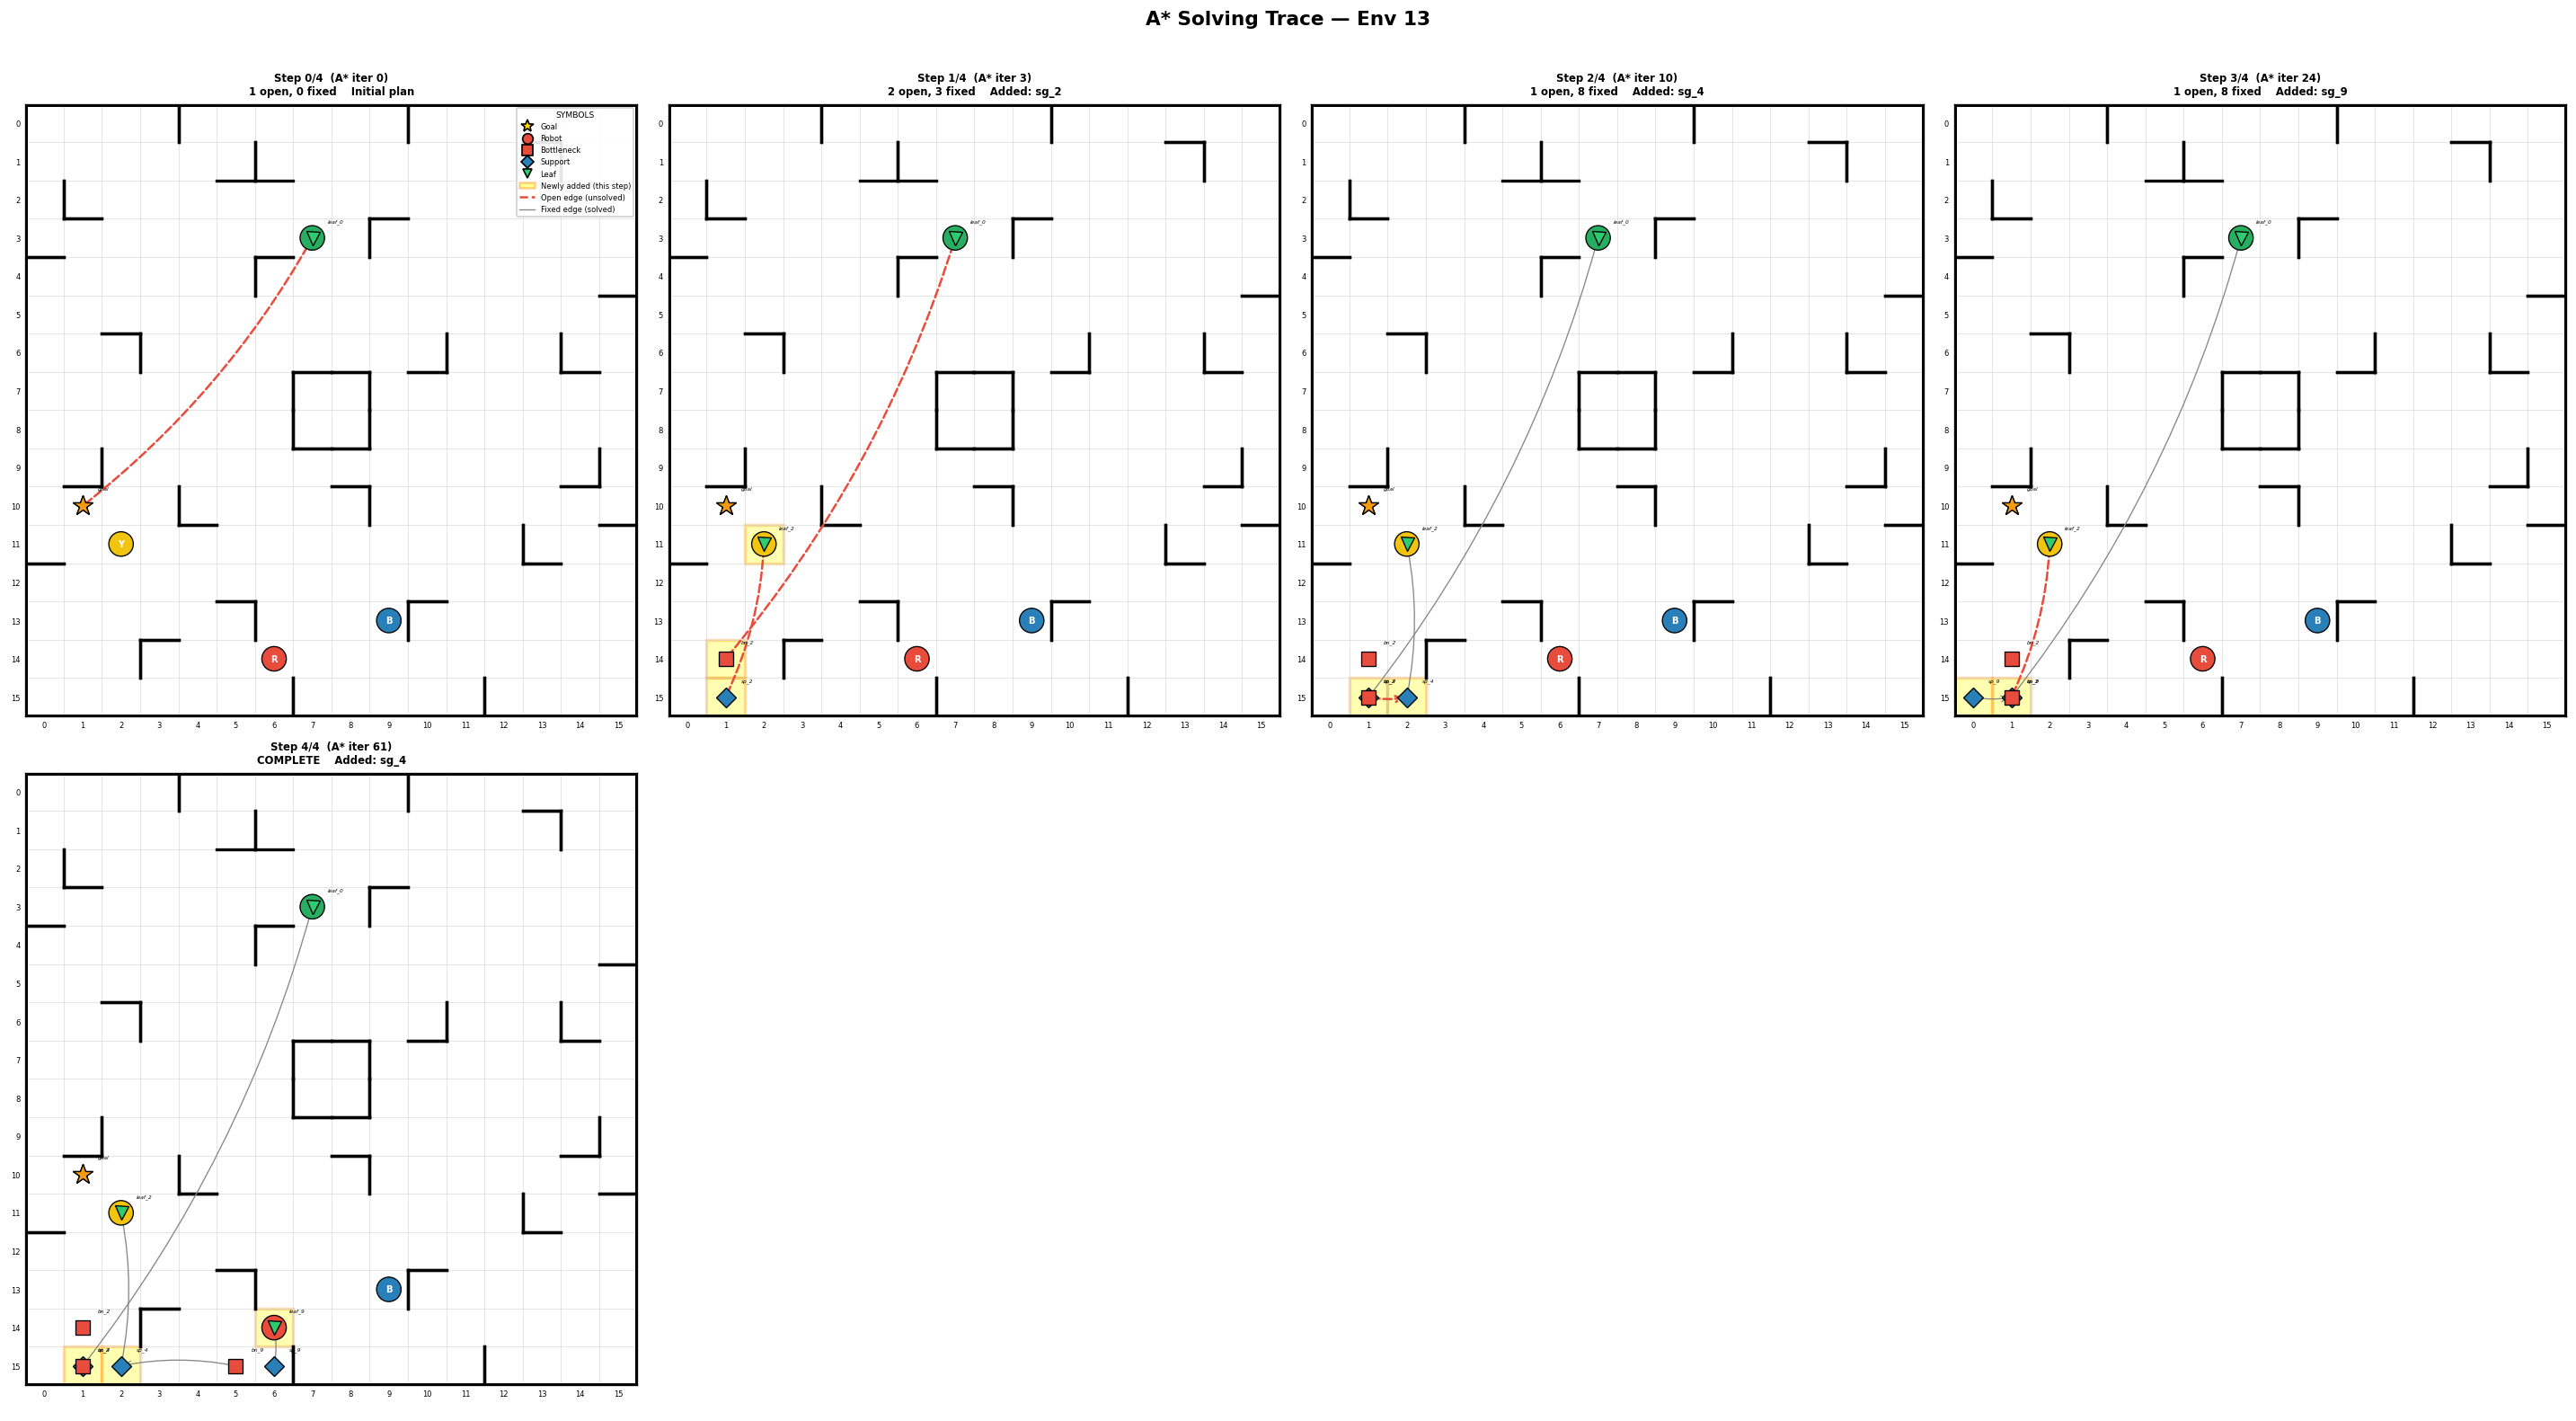

In [16]:
ROBOT_COLORS = {'Red':'#e74c3c','Green':'#27ae60','Blue':'#2980b9','Yellow':'#f1c40f'}

def _draw_walls_from_env(ax, grid_env):
    """Draw walls from GridEnv grid_data."""
    gd = grid_env.grid_data
    for y in range(16):
        for x in range(16):
            idx = y * 16 + x
            cell = gd[idx] if gd and idx < len(gd) else 'X'
            if 'N' in cell and y > 0:
                ax.plot([x-0.5, x+0.5], [y-0.5, y-0.5], 'k-', lw=2)
            if 'S' in cell and y < 15:
                ax.plot([x-0.5, x+0.5], [y+0.5, y+0.5], 'k-', lw=2)
            if 'W' in cell and x > 0:
                ax.plot([x-0.5, x-0.5], [y-0.5, y+0.5], 'k-', lw=2)
            if 'E' in cell and x < 15:
                ax.plot([x+0.5, x+0.5], [y-0.5, y+0.5], 'k-', lw=2)
    for s in [[-0.5,15.5,-0.5,-0.5],[-0.5,15.5,15.5,15.5],
              [-0.5,-0.5,-0.5,15.5],[15.5,15.5,-0.5,15.5]]:
        ax.plot(s[:2], s[2:], 'k-', lw=3)


def draw_plan_step(ax, grid_env, state, plan_data, step_idx, total_steps,
                   prev_nodes=None):
    """Draw one step of the solving trace on ax."""
    plan = plan_data['plan']
    g = plan.g
    _setup_grid(ax)
    _draw_walls_from_env(ax, grid_env)

    # Goal
    gx, gy = state.target
    ax.plot(gx, gy, '*', ms=14, color='gold', mec='black', mew=0.8, zorder=5)

    # Robots
    for robot in [state.target_robot] + list(state.helpers):
        rx, ry = int(robot.position[0]), int(robot.position[1])
        fc = ROBOT_COLORS.get(robot.color, '#888')
        ax.add_patch(plt.Circle((rx, ry), 0.32, fc=fc, ec='black', lw=0.8, zorder=4))
        ax.text(rx, ry, robot.color[0], ha='center', va='center',
                fontsize=6, fontweight='bold', color='white', zorder=6)

    # Determine which nodes are new in this step
    current_nodes = set(g.nodes())
    new_nodes = current_nodes - prev_nodes if prev_nodes else set()

    # Draw edges
    for u, v, edata in g.edges(data=True):
        status = edata.get('status', 'fixed')
        u_data = g.nodes[u]
        v_data = g.nodes[v]
        if 'pos' in u_data and 'pos' in v_data:
            x0, y0 = int(u_data['pos'][0]), int(u_data['pos'][1])
            x1, y1 = int(v_data['pos'][0]), int(v_data['pos'][1])
            ls = '--' if status == 'open' else '-'
            ec = '#e74c3c' if status == 'open' else '#888'
            lw = 1.5 if status == 'open' else 0.8
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                       arrowprops=dict(arrowstyle='->', color=ec, lw=lw,
                                      linestyle=ls, connectionstyle='arc3,rad=0.1'),
                       zorder=2)

    # Draw plan nodes
    type_markers = {'goal':('*',14), 'bottleneck':('s',10), 'support':('D',9), 'leaf':('v',9)}
    type_colors_default = {'goal':'#f39c12', 'bottleneck':'#e74c3c', 'support':'#2980b9', 'leaf':'#2ecc71'}

    for nid, data in g.nodes(data=True):
        if 'pos' not in data:
            continue
        ntype = data['ntype']
        if ntype == 'subgoal':
            continue
        x, y = int(data['pos'][0]), int(data['pos'][1])
        marker, ms = type_markers.get(ntype, ('o', 8))
        fc = type_colors_default.get(ntype, '#888')

        # Highlight newly added nodes
        if nid in new_nodes:
            ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                         fc='#ffff00', alpha=0.3, ec='#ff8800', lw=2, zorder=1))

        ax.plot(x, y, marker=marker, markersize=ms, color=fc,
                markeredgecolor='black', markeredgewidth=0.8, zorder=7)
        ax.text(x+0.4, y-0.4, nid, fontsize=3.5, color='black',
                zorder=8, fontstyle='italic')

    # Title
    n_open = sum(1 for _,_,d in g.edges(data=True) if d.get('status') == 'open')
    n_fixed = sum(1 for _,_,d in g.edges(data=True) if d.get('status') == 'fixed')
    category = plan_data.get('category', '?')
    label = 'COMPLETE' if category == 'complete' else f'{n_open} open, {n_fixed} fixed'

    new_sg = [n for n in new_nodes if g.nodes[n].get('ntype') == 'subgoal']
    subtitle = f'Added: {", ".join(new_sg)}' if new_sg else ('Initial plan' if step_idx == 0 else '')

    ax.set_title(f'Step {step_idx}/{total_steps-1}  (A* iter {plan_data["iteration"]})\n'
                 f'{label}    {subtitle}',
                 fontsize=7, fontweight='bold')


# --- Draw the trace ---
n_steps = len(ancestors)
ncols = min(4, n_steps)
nrows = (n_steps + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6.5*nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncols == 1:
    axes = axes[:, np.newaxis]

prev_nodes = set()
for i, pd in enumerate(ancestors):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    draw_plan_step(ax, grid_env, state, pd, i, n_steps, prev_nodes)
    prev_nodes = set(pd['plan'].g.nodes())

# Hide unused axes
for i in range(n_steps, nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r, c].axis('off')

# Legend on the first axes
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=9,
           markeredgecolor='black', label='Goal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=7,
           markeredgecolor='black', label='Robot'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#e74c3c', markersize=7,
           markeredgecolor='black', label='Bottleneck'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#2980b9', markersize=6,
           markeredgecolor='black', label='Support'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='#2ecc71', markersize=6,
           markeredgecolor='black', label='Leaf'),
    mpatches.Patch(fc='#ffff00', alpha=0.4, ec='#ff8800', lw=1.5,
                   label='Newly added (this step)'),
    Line2D([0], [0], color='#e74c3c', lw=1.5, ls='--', label='Open edge (unsolved)'),
    Line2D([0], [0], color='#888', lw=0.8, label='Fixed edge (solved)'),
]
axes[0, 0].legend(handles=legend_elements, loc='upper right', fontsize=5,
                  framealpha=0.9, title='SYMBOLS', title_fontsize=5.5)

fig.suptitle(f'A* Solving Trace — Env {TRACE_ENV_ID}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()